In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date

from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, root_mean_squared_error

The primary goal of RFM (Recency, Frequency, Monetary) Analysis is to move away from "one-size-fits-all" marketing and toward Data-Driven Personalization. Instead of treating every customer the same, we categorize them based on their actual past behavior to predict their future value.

**Examples, how we can use our RFM segmentation:**
* By identifying who our high-spenders are, we can focus our resources on keeping them happy. It is statistically much cheaper to retain an existing VIP than to acquire a new customer.
* RFM acts as an early warning system. When a customer moves from "Recent" to "Not Recent", the data flags them before they disappear forever. This allows us to trigger a "win-back" campaign at the exact moment they are drifting away.

### Data Preparation and Scaling

In [2]:
ecomm_dataset = pd.read_csv('ecommerce_customer_behavior_dataset_v2.csv')

In [3]:
# change date format
ecomm_dataset['Date'] = ecomm_dataset['Date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').date())

In [4]:
ecomm_dataset.head(2)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2


In [300]:
max_date = ecomm_dataset.Date.max()
min_date = ecomm_dataset.Date.min()

# For RFM (Recency, Frequency, Monetary) we need features that could show us these characteristics
# For each user gather aggregations and statistics
ecomm_dataset['Order_Last3Monts'] = ecomm_dataset['Date'].apply(lambda x: 1 if (max_date - x).days <= 60 else 0)

u_profile = ecomm_dataset.groupby(by = 'Customer_ID').agg({
    'Order_ID': 'count', # count number of orders per customer
    'Date': ['min', 'max'], # dates of the first and last order in our data (for Recency and Frequency in RFM)
    'Total_Amount': ['sum', 'mean'], # that`s actual amount user payed after discount
    'Is_Returning_Customer': 'sum', # that`s needed to assess time of first order and user status
    'Order_Last3Monts': 'sum'
})
u_profile.columns = ['_'.join(i) for i in u_profile.columns.values]
u_profile.reset_index(inplace = True)

# if we have flag = Is_Returning_Customer for all orders, that means user`s first order was before min(Date) in our dataset 
u_profile['New_Customer'] = 1
for i in range(u_profile.shape[0]):
    if u_profile['Order_ID_count'][i] == u_profile['Is_Returning_Customer_sum'][i]:
        u_profile.loc[i,'Date_min'] = min_date
        u_profile.loc[i,'New_Customer'] = 0
    else:
        next

# Recency Metrics:
# Diff between [Last Order Date] and [Max Date] in dataset
u_profile['Recency_Last_Order_Days'] = u_profile['Date_max'].apply(lambda x: (max_date - x).days + 1)
u_profile['Recency_Has_Order_Last60Days'] = u_profile['Recency_Last_Order_Days'].apply(lambda x: 1 if x <= 60 else 0)
# ----
# observation period for each user (in ?)
u_profile['Observation_Period'] = u_profile['Date_min'].apply(lambda x: (max_date - x).days + 1)
# ----
# Frequency Metrics:
# number of orders per period
u_profile['Frequency_Orders_Period'] = u_profile['Order_ID_count'] / (u_profile['Observation_Period'].apply(
    lambda x: math.ceil(x / 30)
))

# has more than 1 order (overall)
u_profile['Frequency_N_Orders'] = u_profile['Order_ID_count'].apply(lambda x: 0 if x == 1 else 1)
# ----
# Monetary Metrics:
# Total_Amount_sum
u_profile['Monetary_Amount_SUM'] = u_profile['Total_Amount_sum']
# Total_Amount_mean (per order)
u_profile['Monetary_Amount_AVG'] = u_profile['Total_Amount_mean']
# money from min date for each user per day
u_profile['Monetary_Amount_Days'] = u_profile['Total_Amount_sum'] / u_profile['Observation_Period']

u_profile.head(2)

,Customer_ID,Order_ID_count,Date_min,Date_max,Total_Amount_sum,Total_Amount_mean,Is_Returning_Customer_sum,Order_Last3Monts_sum,New_Customer,Recency_Last_Order_Days,Recency_Has_Order_Last60Days,Observation_Period,Frequency_Orders_Period,Frequency_N_Orders,Monetary_Amount_SUM,Monetary_Amount_AVG,Monetary_Amount_Days
0,CUST_00001,3,2023-01-01,2023-12-05,2199.63,733.21,3,0,0,112,0,450,0.0,1,2199.63,733.21,4.888067
1,CUST_00002,2,2023-01-01,2023-06-16,809.90,404.95,2,0,0,284,0,450,0.0,1,809.90,404.95,1.799778


In [301]:
rfm_features = u_profile.loc[:, ['New_Customer', 'Recency_Last_Order_Days', 'Recency_Has_Order_Last60Days', 'Frequency_Orders_Period',
                                 'Frequency_N_Orders', 'Monetary_Amount_SUM', 'Monetary_Amount_AVG', 'Monetary_Amount_Days']]
rfm_features.index = u_profile.Customer_ID

Number of numeric factors 8


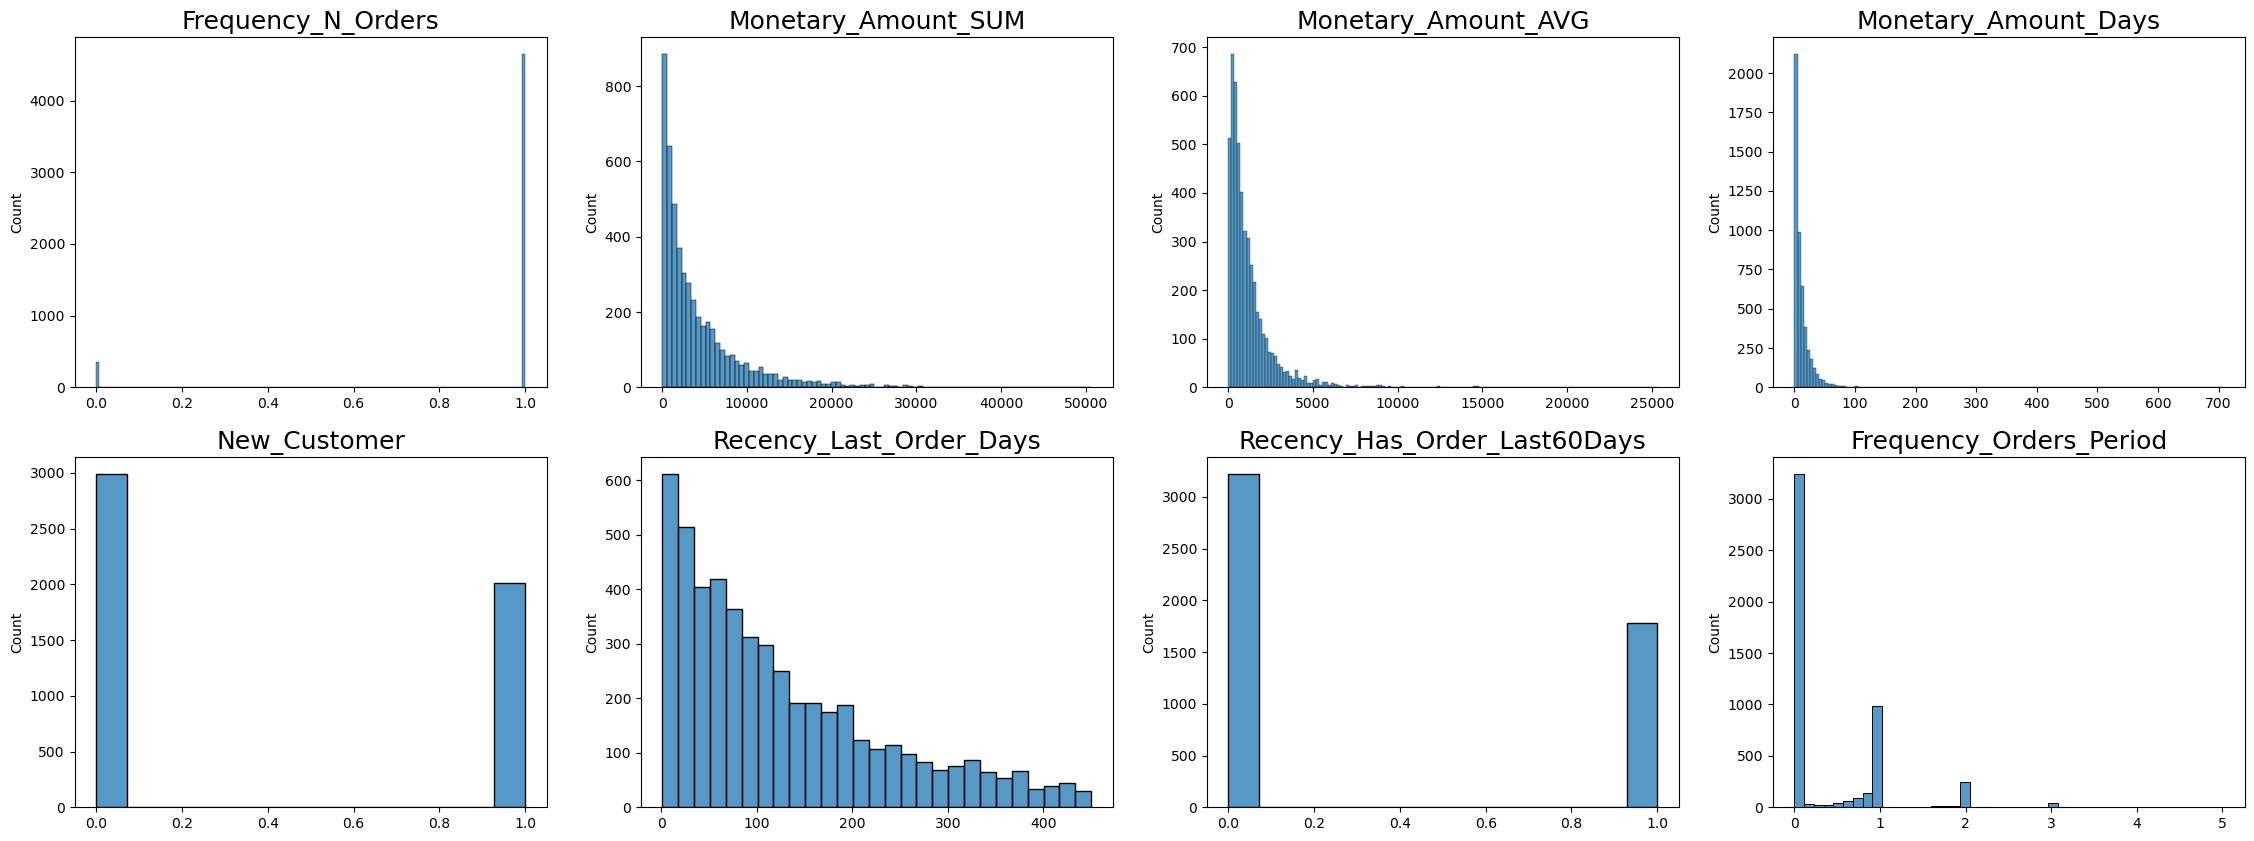

,New_Customer,Recency_Last_Order_Days,Recency_Has_Order_Last60Days,Frequency_Orders_Period,Frequency_N_Orders,Monetary_Amount_SUM,Monetary_Amount_AVG,Monetary_Amount_Days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.402000,125.716400,0.355800,0.406690,0.930200,4355.810518,1262.886447,11.872808
std,0.490351,108.050972,0.478803,0.651982,0.254835,5274.546636,1539.039257,19.917746
min,0.000000,1.000000,0.000000,0.000000,0.000000,14.280000,14.280000,0.031733
25%,0.000000,39.000000,0.000000,0.000000,1.000000,889.410000,387.121667,2.400256
50%,0.000000,94.000000,0.000000,0.000000,1.000000,2493.925000,794.481667,6.651651
75%,1.000000,185.000000,1.000000,0.975501,1.000000,5796.297500,1550.695000,14.940844
max,1.000000,450.000000,1.000000,5.011136,1.000000,50628.150000,25314.075000,707.841176


In [302]:
columns = rfm_features.columns

print('Number of numeric factors {}'.format(len(columns)))
fig, ax = plt.subplots(2, 4, figsize = (28, 10))

for i in range(2):
    if i == 1:
        col_name = columns[:4]
    else:
        col_name = columns[4:]
    for j in range(4):
        sns.histplot(rfm_features[col_name[j]], ax = ax[i][j])
        ax[i][j].set_title(col_name[j], fontsize=18)
        ax[i][j].set(xlabel = None)
plt.show()

rfm_features.loc[:, columns].describe()

In [420]:
# what if we clean all extreme values?
customers_to_drop = []
print('Extreme Outliers Sample Sise for Each Column:')
for col in columns:
    q75 = rfm_features[col].quantile(q = 0.75)
    q25 = rfm_features[col].quantile(q = 0.25)
    iqr = (q75 - q25)
    min_ = q25 - (3 * iqr)
    max_ = q75 + (3 * iqr)
    filtered_data = rfm_features[(rfm_features[col] < min_)|(rfm_features[col] > max_)].reset_index()
    if filtered_data.shape[0] > 0:
        print('* Column Name: {}; Number of Outliers: {}'.format(col, filtered_data.shape[0]))
        customers_to_drop.append(filtered_data['Customer_ID'])
    else:
        next
print('\n')
print('Extreme Outliers Share {}'.format(len(pd.concat(customers_to_drop).drop_duplicates()) / rfm_features.shape[0]))

Extreme Outliers Sample Sise for Each Column:
* Column Name: Monetary_Amount_AVG; Number of Outliers: 147
* Column Name: Frequency_N_Orders; Number of Outliers: 349


Extreme Outliers Share 0.0962


#### Scaling

In [313]:
# log scaling
log_sc_columns = ['Monetary_Amount_SUM', 'Monetary_Amount_Days']
log_tr_features = rfm_features.loc[:,log_sc_columns]
for col in log_sc_columns:
    log_tr_features[col] = rfm_features[col].apply(lambda x: np.log1p(x))
log_tr_features.head(2)

,Monetary_Amount_SUM,Monetary_Amount_Days
Customer_ID,,
CUST_00001,7.696499,1.772928
CUST_00002,6.698145,1.029540


In [314]:
qt_columns = ['Monetary_Amount_AVG', 'Recency_Last_Order_Days', 'Frequency_Orders_Period']
qt = QuantileTransformer(n_quantiles=5, random_state=0)
quantile_tr_features = pd.DataFrame(
    qt.fit_transform(
    rfm_features.loc[:,qt_columns]
    )
)
quantile_tr_features.columns = qt.get_feature_names_out()
quantile_tr_features.index = rfm_features.index
quantile_tr_features.head(2)

,Monetary_Amount_AVG,Recency_Last_Order_Days,Frequency_Orders_Period
Customer_ID,,,
CUST_00001,0.462397,0.549451,0.0
CUST_00002,0.260941,0.843396,0.0


In [315]:
scaler = StandardScaler()
numeric_features_scaled = pd.DataFrame(
    scaler.fit_transform(
    pd.concat([
        rfm_features.loc[:,['Recency_Has_Order_Last60Days', 'New_Customer', 'Frequency_N_Orders']],
        log_tr_features,
        quantile_tr_features
    ], axis = 1
             )
    )
)
numeric_features_scaled.columns = scaler.get_feature_names_out()
numeric_features_scaled.head(2)

,Recency_Has_Order_Last60Days,New_Customer,Frequency_N_Orders,Monetary_Amount_SUM,Monetary_Amount_Days,Monetary_Amount_AVG,Recency_Last_Order_Days,Frequency_Orders_Period
0,-0.743178,-0.819903,0.27393,0.030487,-0.245060,-0.030538,0.229200,-0.745555
1,-0.743178,-0.819903,0.27393,-0.703359,-0.972049,-0.844134,1.277046,-0.745555


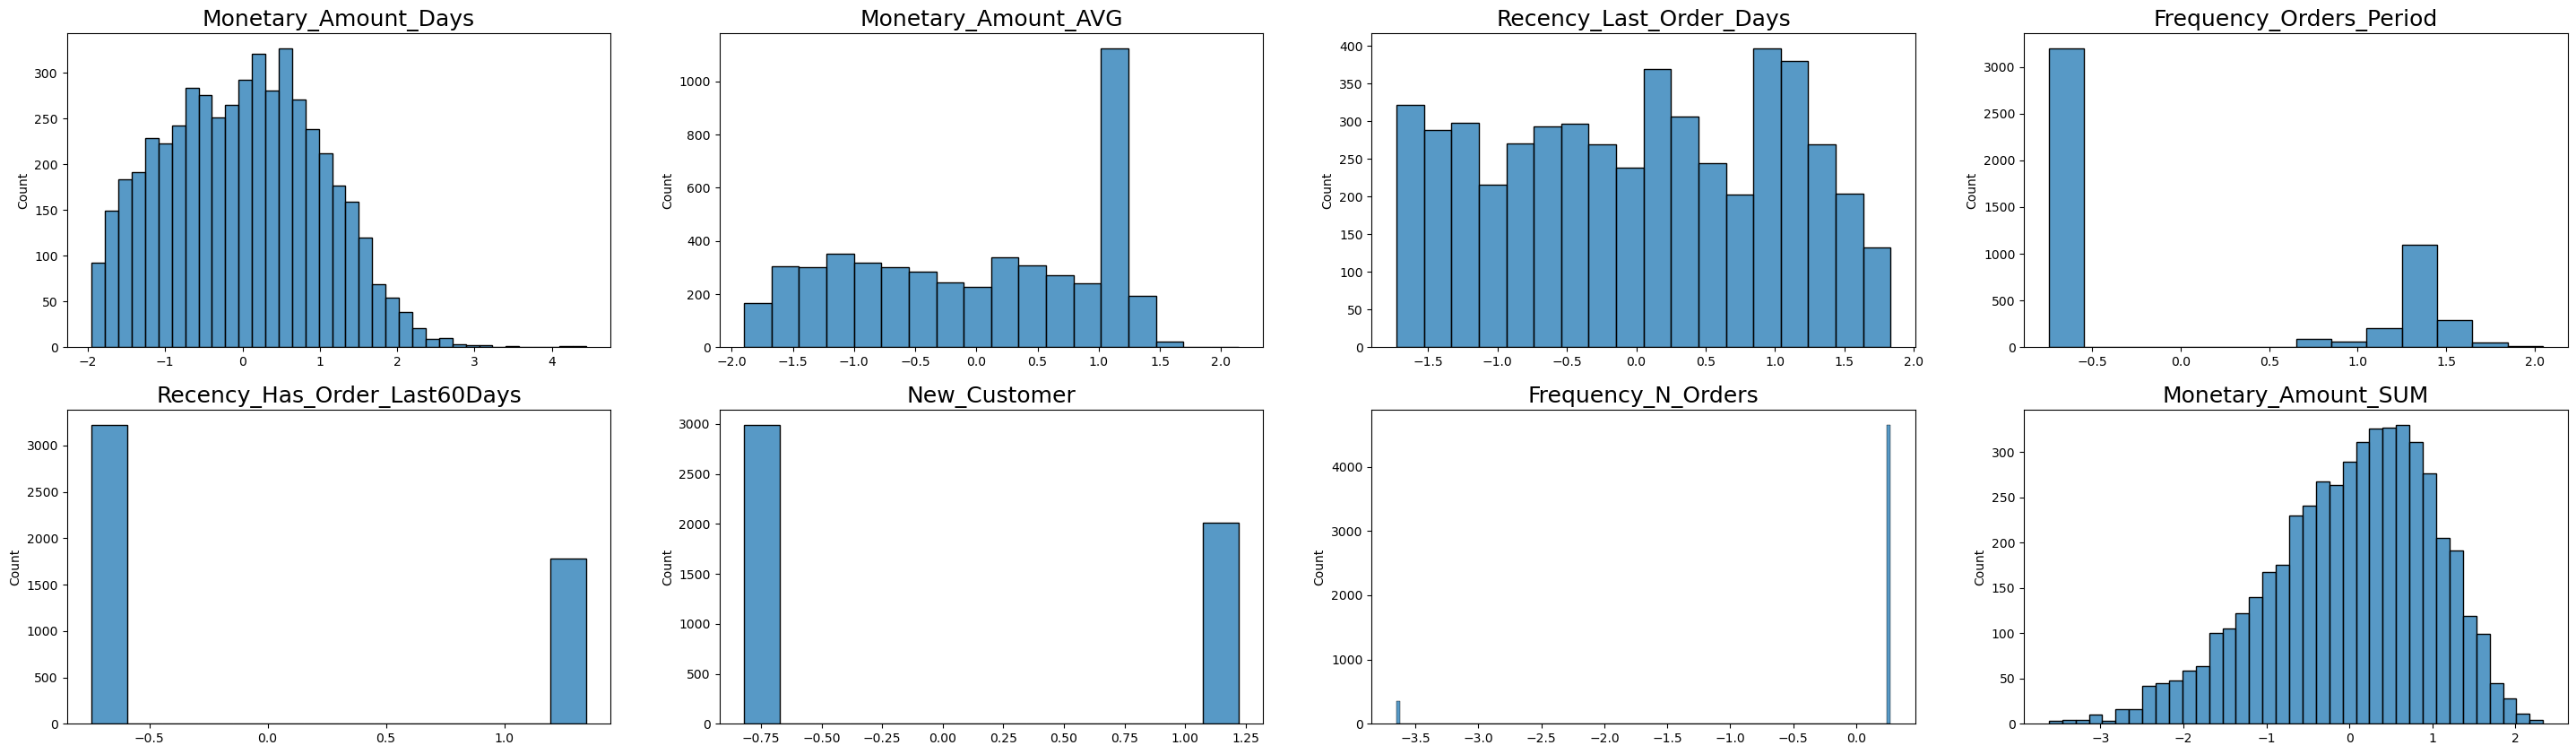

,Recency_Has_Order_Last60Days,New_Customer,Frequency_N_Orders,Monetary_Amount_SUM,Monetary_Amount_Days,Monetary_Amount_AVG,Recency_Last_Order_Days,Frequency_Orders_Period
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,-4.831691e-17,-5.186962e-17,-1.350031e-16,3.453238e-16,5.684342e-18,-3.538503e-16,-5.400125e-17,8.526513e-18
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-7.431776e-01,-8.199029e-01,-3.650568e+00,-3.622708e+00,-1.948326e+00,-1.897969e+00,-1.729459e+00,-7.455555e-01
25%,-7.431776e-01,-8.199029e-01,2.739300e-01,-6.346044e-01,-7.820252e-01,-8.883285e-01,-8.382689e-01,-7.455555e-01
50%,-7.431776e-01,-8.199029e-01,2.739300e-01,1.227476e-01,1.115407e-02,1.212782e-01,5.292092e-02,-7.455555e-01
75%,1.345573e+00,1.219657e+00,2.739300e-01,7.424978e-01,7.289258e-01,1.130918e+00,9.441107e-01,1.349331e+00
max,1.345573e+00,1.219657e+00,2.739300e-01,2.335464e+00,4.439960e+00,2.140618e+00,1.835301e+00,2.047626e+00


In [316]:
columns = numeric_features_scaled.columns
fig, ax = plt.subplots(2, 4, figsize = (36, 10))

for i in range(2):
    if i == 1:
        col_name = columns[:4]
    else:
        col_name = columns[4:]
    for j in range(4):
        sns.histplot(numeric_features_scaled[col_name[j]], ax = ax[i][j])
        ax[i][j].set_title(col_name[j], fontsize=18)
        ax[i][j].set(xlabel = None)
plt.show()

numeric_features_scaled.describe()

### Clusterisation

In [347]:
# features that represent Recency, Frequency and Monetization
# these features improve Silhouette Score the most
columns_set = ['Monetary_Amount_AVG', 'Recency_Has_Order_Last60Days', 'Frequency_N_Orders']
numeric_features_scaled_set = numeric_features_scaled.loc[:,columns_set]

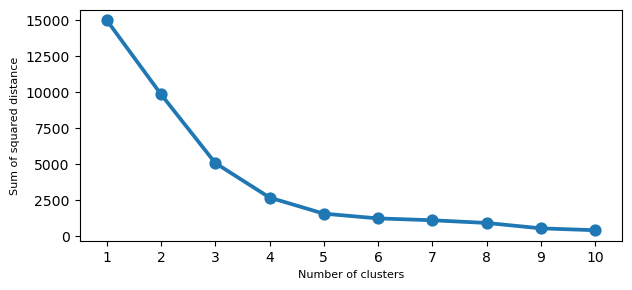

In [386]:
# choose number of clusters (Elbow Method)
inertia_v = []
n_centroids = list(range(1, 11))

for i in n_centroids:
    km = KMeans(n_clusters = i, random_state = 33)
    km.fit(numeric_features_scaled_set)
    inertia_v.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(7, 3))
sns.pointplot(x = n_centroids, y = inertia_v, markers = 'o')
plt.xlabel('Number of clusters', fontsize = 8)
plt.ylabel('Sum of squared distance', fontsize = 8)
plt.show()

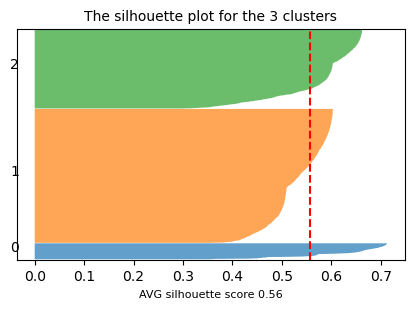

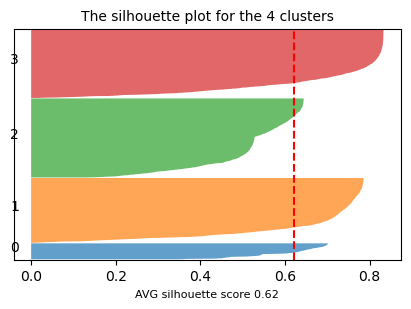

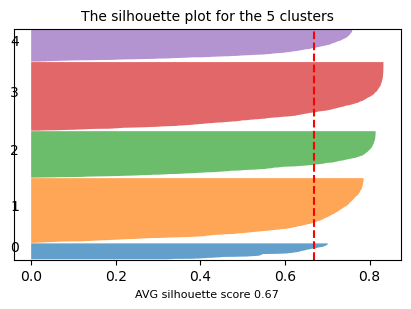

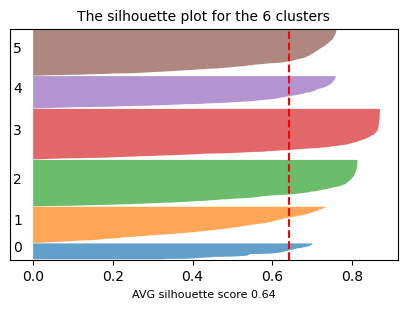

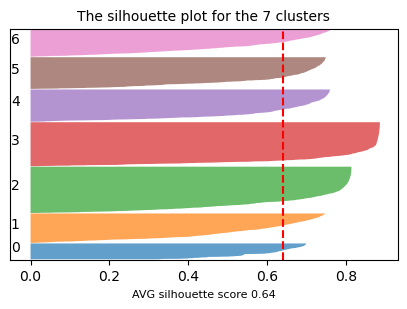

In [392]:
# Silhouette Analysis
# visualisation code from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
n_clusters = range(3, 8)

silhouette_score_list = []
lables_list = []
centroids_list = []

for cl in n_clusters:
    km = KMeans(n_clusters = cl, random_state = 33)
    labels = km.fit_predict(numeric_features_scaled_set)
    centroids = km.cluster_centers_
    lables_list.append(labels)
    centroids_list.append(centroids)
    silhouette_score_ = silhouette_score(numeric_features_scaled_set, labels)
    silhouette_score_list.append(silhouette_score_)

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.set_ylim([0, len(numeric_features_scaled_set) + (cl + 1) * 10])

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(numeric_features_scaled_set, labels)

    y_lower = 10
    for i in range(cl):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        # color = cm.nipy_spectral(float(i) / cl)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            # facecolor=color,
            # edgecolor=color,
            alpha=0.7,
        )
        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title('The silhouette plot for the {} clusters'.format(cl), fontsize = 10)
    ax.set_xlabel('AVG silhouette score {}'.format(round(silhouette_score_, 2)), fontsize = 8)
    # ax.set_ylabel('Cluster label')

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_score_, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks

Monetary_Amount_AVG for cluster 0; Q50 – 434.57
Monetary_Amount_AVG for cluster 1; Q50 – 350.85999999999996
Monetary_Amount_AVG for cluster 2; Q50 – 1418.9428571428573
Monetary_Amount_AVG for cluster 3; Q50 – 1528.63
Monetary_Amount_AVG for cluster 4; Q50 – 421.44375
Order_ID_count for cluster 0; Q50 – 1.0
Order_ID_count for cluster 1; Q50 – 2.0
Order_ID_count for cluster 2; Q50 – 5.0
Order_ID_count for cluster 3; Q50 – 3.0
Order_ID_count for cluster 4; Q50 – 4.0
Recency_Last_Order_Days for cluster 0; Q50 – 208.0
Recency_Last_Order_Days for cluster 1; Q50 – 156.0
Recency_Last_Order_Days for cluster 2; Q50 – 25.0
Recency_Last_Order_Days for cluster 3; Q50 – 139.0
Recency_Last_Order_Days for cluster 4; Q50 – 27.0


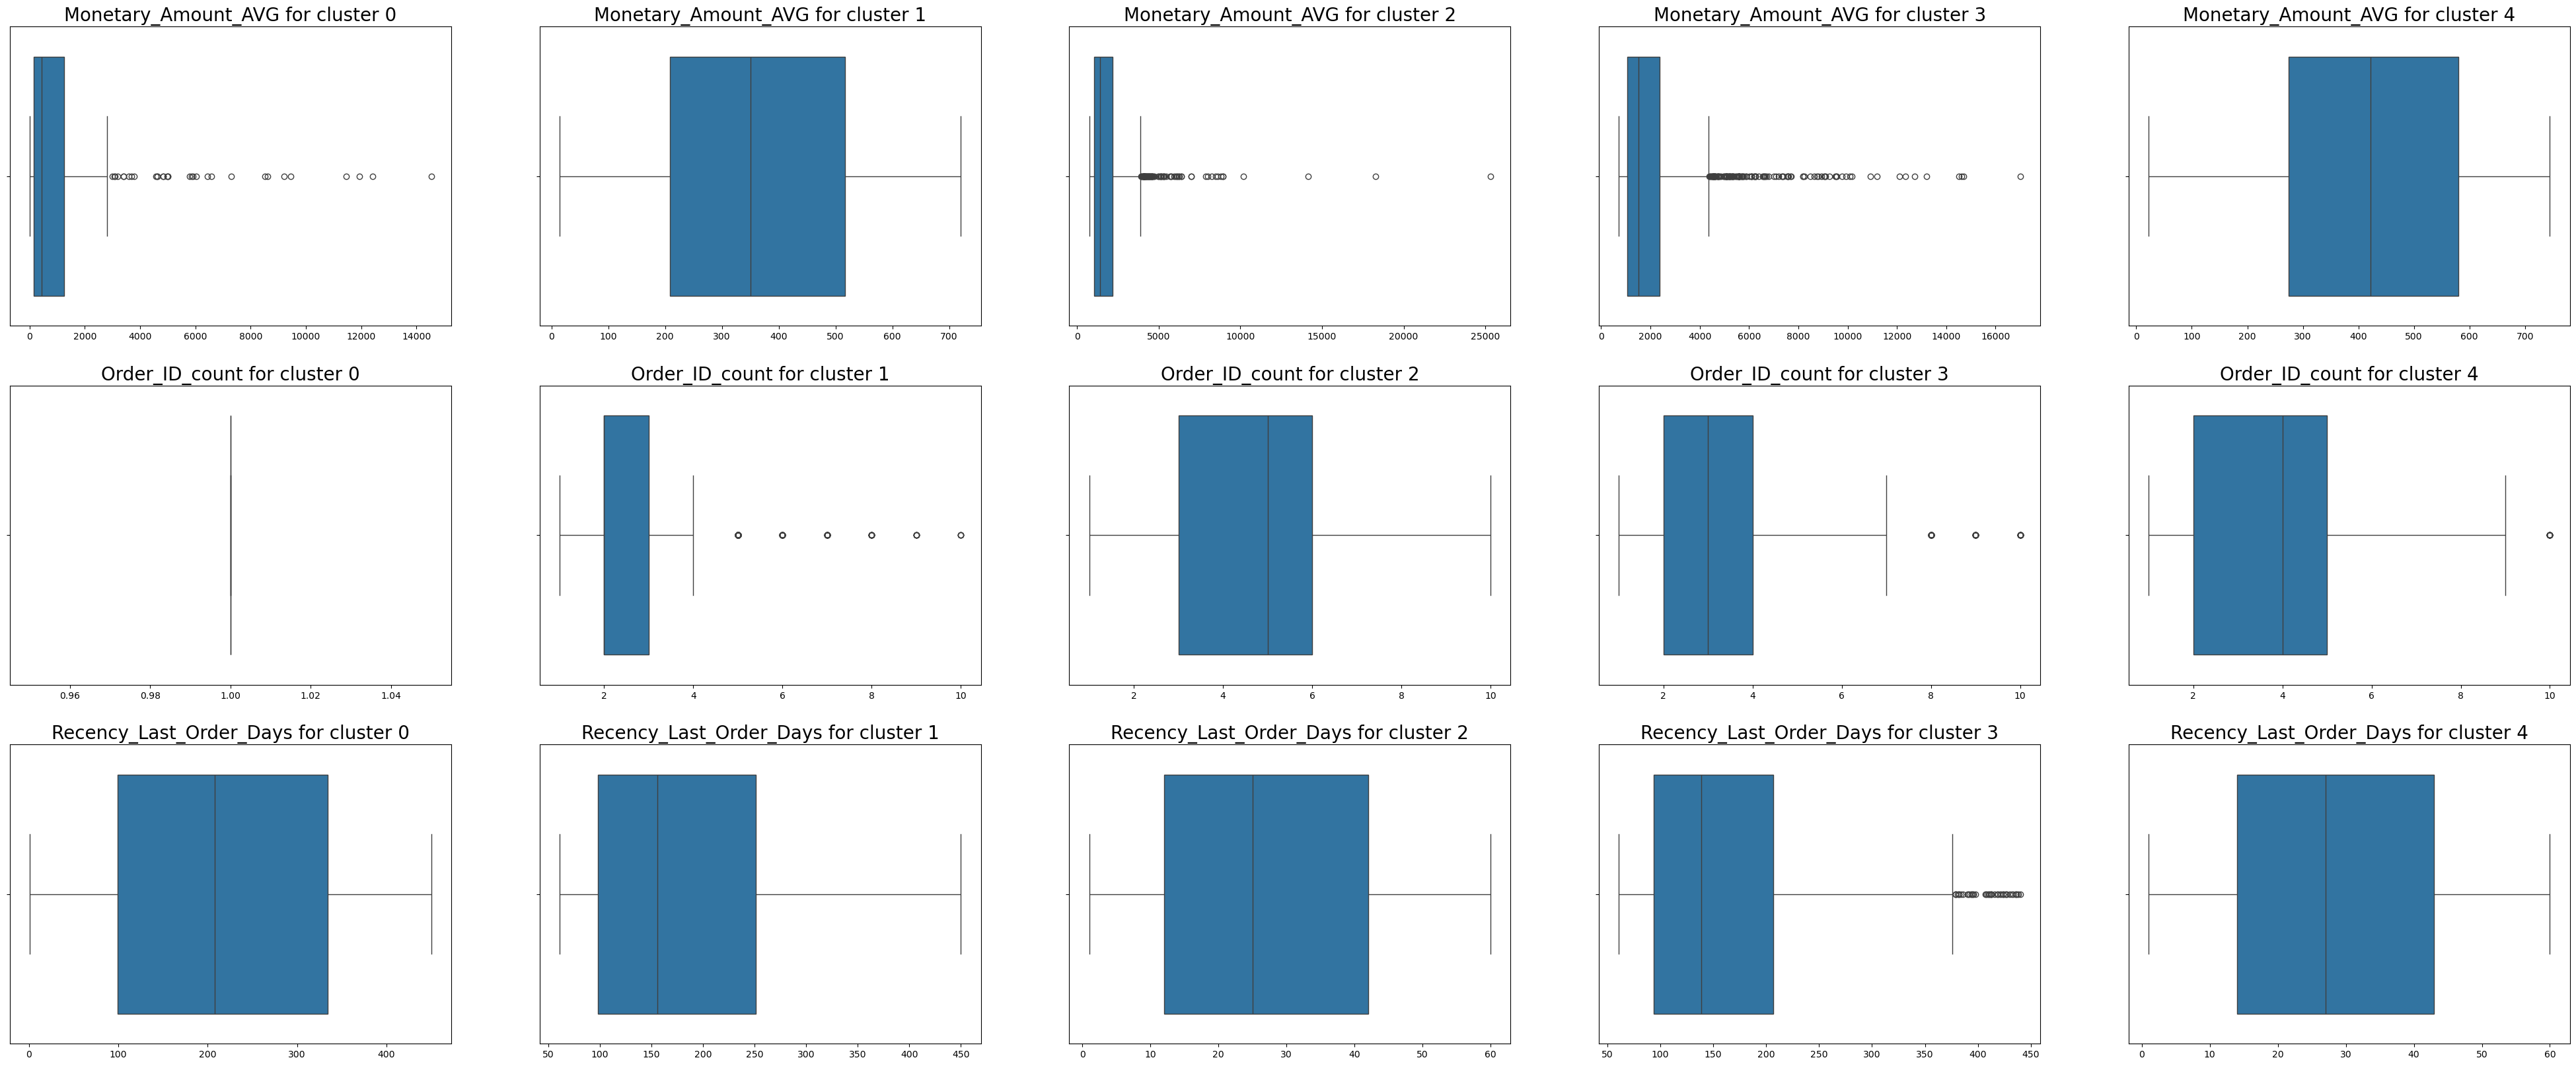

In [437]:
# let`s keep 5 clusters
n_cls = 5

km = KMeans(n_clusters = n_cls, random_state = 33)
labels = km.fit_predict(numeric_features_scaled_set)
u_profile['cluster_labels'] = labels

fig, ax = plt.subplots(3, n_cls, figsize = (50, 20))
columns = ['Monetary_Amount_AVG', 'Order_ID_count', 'Recency_Last_Order_Days']
for col in range(len(columns)):
    for cl in range(n_cls):
        q75 = u_profile[u_profile['cluster_labels'] == cl][columns[col]].quantile(q = 0.75)
        q25 = u_profile[u_profile['cluster_labels'] == cl][columns[col]].quantile(q = 0.25)
        q50 = u_profile[u_profile['cluster_labels'] == cl][columns[col]].quantile(q = 0.5)
        iqr = (q75 - q25)
        print('{} for cluster {}; Q50 – {}'.format(columns[col], cl, q50))
        ax[col][cl].set_title('{} for cluster {}'.format(columns[col], cl), fontsize = 20)
        sns.boxplot(x = u_profile[u_profile['cluster_labels'] == cl][columns[col]], ax = ax[col][cl])
        ax[col][cl].set_xlabel('')

# RFM Customer Segmentation Analysis

This document outlines the results of the RFM (Recency, Frequency, Monetary) clustering and provides a strategic communication roadmap for each segment.

---

## 1. Segment Overview (Translated Results)

The following table summarizes the median values for each cluster identified during the analysis.

| Cluster | Label | Recency (Last Order) | Frequency (Total Orders) | Monetary (Avg. Spend) | Description |
|:---|:---|:---|:---|:---|:---|
| **0** | Hibernating | > 6 months ago | 1 | 430 | One-time buyers who have not returned. |
| **1** | At Risk | ~ 5-6 months ago | 2 | 350 | Low-value customers who are drifting away. |
| **2** | **Champions** | < 1 month ago | 5 | 1400 | High-value, frequent, and recent shoppers. |
| **3** | Potential Loyalists | ~ 3 months ago | 3 | 1530 | Big spenders but haven't purchased recently. |
| **4** | Loyal Budgeters | < 1 month ago | 4 | 420 | Frequent shoppers with low average transaction value. |



---

## 2. Strategic Recommendations

### 🏆 Cluster 2: The Champions (VIPs)
* **Goal:** Reward loyalty and encourage advocacy.
* **Strategy:** Do not overwhelm with discounts. Focus on "Exclusivity."
* **Tactics:** * Early access to new collections/products.
    * Personalized "Thank You" notes or birthday gifts.

### 🐋 Cluster 3: Potential Loyalists (Big Spenders)
* **Goal:** Prevent churn and bring them back into the "Active" cycle.
* **Strategy:** High-touch re-engagement.
* **Tactics:** * "We miss you" email with a personalized recommendation based on past high-value buys.
    * Limited-time incentive (e.g., "15% off your next order, valid for 7 days").

### 📈 Cluster 4: Loyal Budgeters
* **Goal:** Increase **Average Order Value (AOV)**.
* **Strategy:** Use their high frequency to introduce cross-selling and bundling.
* **Tactics:** * "Spend $X more to get Free Shipping."
    * Product bundling (e.g., "Buy 3 for the price of 2").
    * Upsell to premium versions of the low-cost items they currently buy.

### 💤 Clusters 0 & 1: Hibernating / At Risk
* **Goal:** Reactive or prune.
* **Strategy:** Low-cost, high-impact automated reach-out.
* **Tactics:** * One-time "Come Back" offer with a deep discount.
    * If no response after 30 days, move to a "Cold" list to save on marketing costs and maintain email deliverability scores.